## Analysis process - Dianela

In [32]:

import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV, ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt

In [65]:
%pip install fastparquet

Note: you may need to restart the kernel to use updated packages.


In [7]:
import pandas as pd
from pathlib import Path

root = next(p for p in Path.cwd().parents if (p / "config.yml").exists())

df = pd.read_parquet(
    root / "data/processed_data/analysis_panel.parquet", engine='fastparquet'
)
print(df.shape)
print(df.dtypes)
df.head(50)

(17150, 57)
YEAR                               int16
GEOGRAPHY_CODE                  category
GEOGRAPHY_NAME                  category
IS8_SECTOR                      category
EMPLOYEES                        float32
BUSINESSES                       float32
gva_per_hour                     float64
weekly_pay                       float64
employment_rate                  float64
unemployment_rate                float64
gdhi_per_head                    float64
new_enterprises                  float64
deaths_of_enterprises            float64
active_enterprises               float64
high_growth_enterprises          float64
public_transport_to_employer     float64
drive_to_employer                float64
cycle_to_employer                float64
broadband_availability           float64
4g_area_coverage                 float64
ks2_attainment                   float64
gcse_by_age_19                   float64
ofsted                           float64
persistent_absences              float64
pers

,YEAR,GEOGRAPHY_CODE,GEOGRAPHY_NAME,IS8_SECTOR,EMPLOYEES,BUSINESSES,gva_per_hour,weekly_pay,employment_rate,unemployment_rate,...,lq_bus,emp_share,lq_emp,growth_emp,cagr_emp,growth_bus,cagr_bus,related_variety,size_large_share,size_micro_share
0,2016,E06000001,Hartlepool,Advanced Manufacturing,1470.0,25.0,29.84,521.2,69.7,4.6,...,0.840582,0.048197,1.661003,0.010204,0.001693,-0.200000,-0.036508,1.332179,0.000000,1.000000
1,2016,E06000001,Hartlepool,Creative Industries,450.0,110.0,29.84,521.2,69.7,4.6,...,0.355425,0.014754,0.297588,0.744444,0.097176,-0.090909,-0.015760,2.200516,0.000000,1.000000
2,2016,E06000001,Hartlepool,Defence,0.0,0.0,29.84,521.2,69.7,4.6,...,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
3,2016,E06000001,Hartlepool,Digital and Technologies,1510.0,440.0,29.84,521.2,69.7,4.6,...,1.362619,0.049508,0.701351,-0.076159,-0.013116,-0.352273,-0.069823,1.072313,0.000000,1.000000
4,2016,E06000001,Hartlepool,Financial Services,285.0,40.0,29.84,521.2,69.7,4.6,...,0.383770,0.009344,0.157782,-0.070175,-0.012053,0.375000,0.054509,1.213008,0.000000,0.750000
5,2016,E06000001,Hartlepool,Life Sciences,40.0,0.0,29.84,521.2,69.7,4.6,...,0.000000,0.001311,0.456144,0.000000,0.000000,NaN,NaN,0.000000,NaN,NaN
6,2016,E06000001,Hartlepool,Professional and Business Services,2630.0,870.0,29.84,521.2,69.7,4.6,...,0.991174,0.086230,0.483176,-0.019011,-0.003194,-0.264368,-0.049884,1.830641,0.000000,0.965517
7,2016,E06000002,Middlesbrough,Advanced Manufacturing,620.0,25.0,29.50,481.9,68.8,5.1,...,0.587201,0.010622,0.366062,0.153226,0.024045,0.400000,0.057681,1.332179,0.000000,0.800000
8,2016,E06000002,Middlesbrough,Creative Industries,1320.0,180.0,29.50,481.9,68.8,5.1,...,0.406288,0.022614,0.456128,0.431818,0.061650,0.055556,0.009052,2.328951,0.000000,1.000000
9,2016,E06000002,Middlesbrough,Defence,0.0,0.0,29.50,481.9,68.8,5.1,...,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN


In [9]:
print(df.columns.tolist())

['year', 'geography_code', 'geography_name', 'is8_sector', 'employees', 'businesses', 'gva_per_hour', 'weekly_pay', 'employment_rate', 'unemployment_rate', 'gdhi_per_head', 'new_enterprises', 'deaths_of_enterprises', 'active_enterprises', 'high_growth_enterprises', 'public_transport_to_employer', 'drive_to_employer', 'cycle_to_employer', 'broadband_availability', '4g_area_coverage', 'ks2_attainment', 'gcse_by_age_19', 'ofsted', 'persistent_absences', 'persistent_absences_fsm', 'persistent_absences_cla', 'early_years_comms', 'early_years_literacy', 'early_years_maths', 'fe_and_skills_achievements', 'apprenticeship_starts', 'apprenticeship_achievements', 'level_3+_qualifications', 'fe_and_skills_participation', 'female_hle', 'male_hle', 'smokers', 'reception_obesity', 'year_6_obesity', 'adult_obesity', 'cancer_diagnosis', 'under_75_mortality_rate', 'life_satisfaction', 'worthwhile', 'happiness', 'anxiety', 'net_additions', 'lq_bus', 'emp_share', 'lq_emp', 'growth_emp', 'cagr_emp', 'growt

In [10]:
# Rename columns to be safe (adjust if yours differ)
df.columns = df.columns.str.strip().str.lower()
# Expected: year, geography_code, geography_name, is8_sector,
#           emp_count, biz_count

# ── STEP 1: Quick diagnostics on zeros ─────────────────────
print("=== Zero counts per sector (businesses) ===")
zero_diag = (
    df[df["year"] == 2022]
    .groupby("is8_sector")["businesses"]
    .apply(lambda x: (x == 0).sum())
    .rename("n_zeros")
)
total = df[df["year"] == 2022].groupby("is8_sector")["businesses"].count().rename("n_total")
print(pd.concat([zero_diag, total, (zero_diag / total * 100).round(1).rename("pct_zero")], axis=1))

# ── STEP 2: Pivot to cross-section using 2016 and 2022 ─────
# Extract the two years we need
df_2016 = df[df["year"] == 2016][["geography_code", "is8_sector", "businesses", "employees"]].copy()
df_2022 = df[df["year"] == 2022][["geography_code", "is8_sector", "businesses", "employees"]].copy()

df_2016 = df_2016.rename(columns={"businesses": "biz_2016", "employees": "emp_2016"})
df_2022 = df_2022.rename(columns={"businesses": "biz_2022", "employees": "emp_2022"})

# Merge on LAD × sector
cs = df_2016.merge(df_2022, on=["geography_code", "is8_sector"], how="inner")

print(f"\nRows with 2016 AND 2022 data: {len(cs)}")
print(f"Rows missing either year: {len(df_2016) + len(df_2022) - 2*len(cs)}")



=== Zero counts per sector (businesses) ===
                                    n_zeros  n_total  pct_zero
is8_sector                                                    
Advanced Manufacturing                    1      350       0.3
Creative Industries                       1      350       0.3
Defence                                 346      350      98.9
Digital and Technologies                  1      350       0.3
Financial Services                        1      350       0.3
Life Sciences                            98      350      28.0
Professional and Business Services        0      350       0.0

Rows with 2016 AND 2022 data: 2450
Rows missing either year: 0


C:\Users\diane\AppData\Local\Temp\ipykernel_5184\3482334077.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("is8_sector")["businesses"]
C:\Users\diane\AppData\Local\Temp\ipykernel_5184\3482334077.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total = df[df["year"] == 2022].groupby("is8_sector")["businesses"].count().rename("n_total")


In [11]:
print(df.shape)
print(df.columns.tolist())

(17150, 57)
['year', 'geography_code', 'geography_name', 'is8_sector', 'employees', 'businesses', 'gva_per_hour', 'weekly_pay', 'employment_rate', 'unemployment_rate', 'gdhi_per_head', 'new_enterprises', 'deaths_of_enterprises', 'active_enterprises', 'high_growth_enterprises', 'public_transport_to_employer', 'drive_to_employer', 'cycle_to_employer', 'broadband_availability', '4g_area_coverage', 'ks2_attainment', 'gcse_by_age_19', 'ofsted', 'persistent_absences', 'persistent_absences_fsm', 'persistent_absences_cla', 'early_years_comms', 'early_years_literacy', 'early_years_maths', 'fe_and_skills_achievements', 'apprenticeship_starts', 'apprenticeship_achievements', 'level_3+_qualifications', 'fe_and_skills_participation', 'female_hle', 'male_hle', 'smokers', 'reception_obesity', 'year_6_obesity', 'adult_obesity', 'cancer_diagnosis', 'under_75_mortality_rate', 'life_satisfaction', 'worthwhile', 'happiness', 'anxiety', 'net_additions', 'lq_bus', 'emp_share', 'lq_emp', 'growth_emp', 'cagr_

In [12]:
# Look at LQ values for a few LADs you know well
check = df[df["year"] == 2022][["geography_name", "is8_sector", "employees", "businesses", "lq_emp", "lq_bus"]].copy()
print(check[check["geography_name"] == "Leeds"].to_string())
print()
print(check[check["geography_name"] == "City of London"].to_string())
print()
print(check[check["geography_name"] == "Hartlepool"].to_string())

      geography_name                          is8_sector  employees  businesses    lq_emp    lq_bus
16520          Leeds              Advanced Manufacturing     7195.0       325.0  0.565706  0.938352
16521          Leeds                 Creative Industries    31530.0      3345.0  1.207535  0.917195
16522          Leeds                             Defence        0.0         0.0  0.000000  0.000000
16523          Leeds            Digital and Technologies    36605.0      3285.0  1.017562  0.948953
16524          Leeds                  Financial Services    37625.0      1610.0  1.381974  1.284890
16525          Leeds                       Life Sciences     1210.0        40.0  0.706693  0.757055
16526          Leeds  Professional and Business Services   113000.0     10245.0  1.244791  1.040298

       geography_name                          is8_sector  employees  businesses     lq_emp    lq_bus
16541  City of London              Advanced Manufacturing      220.0        75.0   0.014231  0.30

In [36]:
# Compute delta_lq — change in specialisation 2016 to 2022
lq_2016 = df[df["year"] == 2016][["geography_code", "is8_sector", "lq_emp", "lq_bus"]].rename(
    columns={"lq_emp": "lq_emp_2016", "lq_bus": "lq_bus_2016"})

lq_2022 = df[df["year"] == 2022][["geography_code", "is8_sector", "lq_emp", "lq_bus"]].rename(
    columns={"lq_emp": "lq_emp_2022", "lq_bus": "lq_bus_2022"})

lq_change = lq_2016.merge(lq_2022, on=["geography_code", "is8_sector"])
lq_change["delta_lq_emp"] = lq_change["lq_emp_2022"] - lq_change["lq_emp_2016"]
lq_change["delta_lq_bus"] = lq_change["lq_bus_2022"] - lq_change["lq_bus_2016"]

print(lq_change["delta_lq_emp"].describe().round(3))

count    2450.000
mean       -0.012
std         0.921
min       -21.635
25%        -0.109
50%         0.000
75%         0.064
max        27.432
Name: delta_lq_emp, dtype: float64


In [37]:
# Who are the extreme values?
lq_change_named = lq_change.merge(
    df[["geography_code", "geography_name"]].drop_duplicates(),
    on="geography_code"
)

print("Largest increases in specialisation:")
print(lq_change_named.nlargest(5, "delta_lq_emp")[
    ["geography_name", "is8_sector", "lq_emp_2016", "lq_emp_2022", "delta_lq_emp"]])

print("\nLargest decreases:")
print(lq_change_named.nsmallest(5, "delta_lq_emp")[
    ["geography_name", "is8_sector", "lq_emp_2016", "lq_emp_2022", "delta_lq_emp"]])

print("\ndelta_lq_emp by sector — std dev (spread):")
print(lq_change_named.groupby("is8_sector")["delta_lq_emp"].agg(["mean","std","min","max"]).round(3))

Largest increases in specialisation:
     geography_name     is8_sector  lq_emp_2016  lq_emp_2022  delta_lq_emp
1570      Stevenage        Defence    82.718007   110.150019     27.432012
1202       Broxtowe  Life Sciences     0.241199     7.658740      7.417540
779         Gosport        Defence    13.423181    20.187940      6.764760
1591         Bolton        Defence     6.947919    12.990132      6.042213
730      Gloucester        Defence     0.000000     5.965751      5.965751

Largest decreases:
             geography_name     is8_sector  lq_emp_2016  lq_emp_2022  \
625                Basildon        Defence    21.635071     0.000000   
751   Basingstoke and Deane        Defence     8.643787     0.000000   
1503               Worthing  Life Sciences    12.192654     6.230439   
1328                Babergh  Life Sciences     7.989062     2.711383   
1398           Surrey Heath  Life Sciences     5.481578     0.794969   

      delta_lq_emp  
625     -21.635071  
751      -8.643787

C:\Users\diane\AppData\Local\Temp\ipykernel_5184\2451999626.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(lq_change_named.groupby("is8_sector")["delta_lq_emp"].agg(["mean","std","min","max"]).round(3))


In [38]:
# Exclude Defence and check distribution
lq_change_clean = lq_change_named[lq_change_named["is8_sector"] != "Defence"].copy()

print(f"Rows after excluding Defence: {len(lq_change_clean)}")  # expect 350 × 6 = 2100

print("\ndelta_lq_emp summary (no Defence):")
print(lq_change_clean["delta_lq_emp"].describe().round(3))

print("\nBy sector:")
print(lq_change_clean.groupby("is8_sector")["delta_lq_emp"].agg(
    ["mean","std","min","max"]).round(3))

# Also check lq_emp_2022 (your presence Y)
print("\nlq_emp_2022 summary (no Defence):")
print(lq_change_clean["lq_emp_2022"].describe().round(3))

print("\nlq_emp_2022 by sector:")
print(lq_change_clean.groupby("is8_sector")["lq_emp_2022"].agg(
    ["mean","std","min","max"]).round(3))

Rows after excluding Defence: 2100

delta_lq_emp summary (no Defence):
count    2100.000
mean       -0.021
std         0.524
min        -5.962
25%        -0.124
50%        -0.016
75%         0.079
max         7.418
Name: delta_lq_emp, dtype: float64

By sector:
                                     mean    std    min    max
is8_sector                                                    
Advanced Manufacturing              0.021  0.436 -2.893  2.272
Creative Industries                -0.021  0.223 -0.809  2.132
Defence                               NaN    NaN    NaN    NaN
Digital and Technologies           -0.046  0.213 -0.884  1.030
Financial Services                 -0.036  0.209 -1.389  0.973
Life Sciences                      -0.019  1.130 -5.962  7.418
Professional and Business Services -0.023  0.212 -1.735  1.663

lq_emp_2022 summary (no Defence):
count    2100.000
mean        0.891
std         1.053
min         0.000
25%         0.362
50%         0.620
75%         1.024
max       

C:\Users\diane\AppData\Local\Temp\ipykernel_5184\2495468853.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(lq_change_clean.groupby("is8_sector")["delta_lq_emp"].agg(
C:\Users\diane\AppData\Local\Temp\ipykernel_5184\2495468853.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(lq_change_clean.groupby("is8_sector")["lq_emp_2022"].agg(


In [39]:
# Check remaining outliers — likely Life Sciences in small LADs
threshold = 3  # LQ change > 3 in either direction is extreme

outliers = lq_change_clean[
    (lq_change_clean["delta_lq_emp"].abs() > threshold)
][["geography_name", "is8_sector", 
   "lq_emp_2016", "lq_emp_2022", 
   "delta_lq_emp"]].sort_values("delta_lq_emp", key=abs, ascending=False)

print(f"Outliers with |delta_lq| > 3: {len(outliers)}")
print(outliers.to_string(index=False))

# Distribution by sector — which sector still has the widest spread?
print("\nBy sector:")
print(lq_change_clean.groupby("is8_sector")["delta_lq_emp"].agg(
    n="count", mean="mean", std="std", 
    min="min", max="max").round(3))

Outliers with |delta_lq| > 3: 15
       geography_name    is8_sector  lq_emp_2016  lq_emp_2022  delta_lq_emp
             Broxtowe Life Sciences     0.241199     7.658740      7.417540
             Worthing Life Sciences    12.192654     6.230439     -5.962215
              Babergh Life Sciences     7.989062     2.711383     -5.277680
           Midlothian Life Sciences     0.349557     5.204171      4.854614
         Surrey Heath Life Sciences     5.481578     0.794969     -4.686609
  Vale of White Horse Life Sciences     3.079420     7.416686      4.337266
               Slough Life Sciences     1.302185     5.471506      4.169321
               Oxford Life Sciences     1.080333     5.188827      4.108495
 South Cambridgeshire Life Sciences     5.674436     9.717142      4.042706
            Eastleigh Life Sciences    11.452764     7.555053     -3.897710
     Clackmannanshire Life Sciences     0.000000     3.405284      3.405284
                 Adur Life Sciences     3.390783     0.

C:\Users\diane\AppData\Local\Temp\ipykernel_5184\3219542488.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(lq_change_clean.groupby("is8_sector")["delta_lq_emp"].agg(


In [40]:
# Check: are Life Sciences outliers the zero-base LADs?
ls = lq_change_clean[lq_change_clean["is8_sector"] == "Life Sciences"].copy()

print("Life Sciences — extreme delta_lq cases:")
print(ls[ls["delta_lq_emp"].abs() > 2][
    ["geography_name", "lq_emp_2016", "lq_emp_2022", "delta_lq_emp"]
].sort_values("delta_lq_emp", key=abs, ascending=False).to_string(index=False))

Life Sciences — extreme delta_lq cases:
       geography_name  lq_emp_2016  lq_emp_2022  delta_lq_emp
             Broxtowe     0.241199     7.658740      7.417540
             Worthing    12.192654     6.230439     -5.962215
              Babergh     7.989062     2.711383     -5.277680
           Midlothian     0.349557     5.204171      4.854614
         Surrey Heath     5.481578     0.794969     -4.686609
  Vale of White Horse     3.079420     7.416686      4.337266
               Slough     1.302185     5.471506      4.169321
               Oxford     1.080333     5.188827      4.108495
 South Cambridgeshire     5.674436     9.717142      4.042706
            Eastleigh    11.452764     7.555053     -3.897710
     Clackmannanshire     0.000000     3.405284      3.405284
                 Adur     3.390783     0.000000     -3.390783
Basingstoke and Deane     4.610020     1.309652     -3.300368
            Sevenoaks     4.377544     1.080372     -3.297172
          North Devon     7.06

In [41]:
# ── Option A: Pool all 6 sectors, winsorise Life Sciences outliers
# Cap delta_lq at 99th percentile to prevent Life Sciences from dominating

p01 = lq_change_clean["delta_lq_emp"].quantile(0.01)
p99 = lq_change_clean["delta_lq_emp"].quantile(0.99)
lq_change_clean["delta_lq_win"] = lq_change_clean["delta_lq_emp"].clip(p01, p99)

print(f"Winsorised range: {p01:.3f} to {p99:.3f}")
print(lq_change_clean["delta_lq_win"].describe().round(3))

# ── Option B: Exclude Life Sciences entirely from growth model
# Run LASSO on 5 clean sectors only (350 × 5 = 1750 rows)
lq_clean_5 = lq_change_clean[lq_change_clean["is8_sector"] != "Life Sciences"].copy()
print(f"\nRows with 5 sectors: {len(lq_clean_5)}")
print(lq_clean_5.groupby("is8_sector")["delta_lq_emp"].std().round(3))

# ── Option C: Run Life Sciences as a separate model
# Its drivers may genuinely differ from the other 5 sectors
ls_only = lq_change_clean[lq_change_clean["is8_sector"] == "Life Sciences"].copy()
print(f"\nLife Sciences standalone rows: {len(ls_only)}")  # 350 LADs

Winsorised range: -1.345 to 1.667
count    2100.000
mean       -0.021
std         0.352
min        -1.345
25%        -0.124
50%        -0.016
75%         0.079
max         1.667
Name: delta_lq_win, dtype: float64

Rows with 5 sectors: 1750
is8_sector
Advanced Manufacturing                0.436
Creative Industries                   0.223
Defence                                 NaN
Digital and Technologies              0.213
Financial Services                    0.209
Life Sciences                           NaN
Professional and Business Services    0.212
Name: delta_lq_emp, dtype: float64

Life Sciences standalone rows: 350


C:\Users\diane\AppData\Local\Temp\ipykernel_5184\719748405.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(lq_clean_5.groupby("is8_sector")["delta_lq_emp"].std().round(3))


In [26]:
# ────────────────────────────────────────────────────────────
# 0. SETUP — variables confirmed from codebook + indicators.py
# ────────────────────────────────────────────────────────────

LAD_INDICATORS = [
    # Human capital
    "level_3+_qualifications",
    "gcse_by_age_19",
    "apprenticeship_starts",
    "apprenticeship_achievements",
    "fe_and_skills_participation",
    # Entrepreneurial discovery
    "new_enterprises",
    "deaths_of_enterprises",
    "active_enterprises",
    "high_growth_enterprises",
    # Connectivity
    "public_transport_to_employer",
    "drive_to_employer",
    "cycle_to_employer",
    "broadband_availability",
    "4g_area_coverage",
    # Labour market + place
    "unemployment_rate",
    "net_additions",
    # Derived
    "related_variety",
]

# Excluded (reverse causality): gva_per_hour, weekly_pay,
#   gdhi_per_head, employment_rate
# Excluded (no EEG mechanism): all health/wellbeing variables
# Excluded (geography mismatch): ks2, ofsted, persistent_absences,
#   fe_and_skills_achievements, female_hle, male_hle




In [27]:
# ────────────────────────────────────────────────────────────
# 1. BUILD CROSS-SECTION WITH DELTA_LQ
# ────────────────────────────────────────────────────────────

# Get ONS indicators from any year (time-invariant — same value all years)
indicators_cs = (
    df[df["year"] == 2022]
    [["geography_code", "geography_name"] + LAD_INDICATORS]
    .drop_duplicates("geography_code")
)

# Compute delta_lq and lq_2022
lq_2016 = df[df["year"] == 2016][["geography_code", "is8_sector", "lq_emp", "lq_bus"]].rename(
    columns={"lq_emp": "lq_emp_2016", "lq_bus": "lq_bus_2016"})
lq_2022 = df[df["year"] == 2022][["geography_code", "is8_sector", "lq_emp", "lq_bus"]].rename(
    columns={"lq_emp": "lq_emp_2022", "lq_bus": "lq_bus_2022"})

cs = lq_2016.merge(lq_2022, on=["geography_code", "is8_sector"])
cs["delta_lq_emp"] = cs["lq_emp_2022"] - cs["lq_emp_2016"]
cs["delta_lq_bus"] = cs["lq_bus_2022"] - cs["lq_bus_2016"]

# Merge indicators
cs = cs.merge(indicators_cs, on="geography_code", how="left")

In [28]:
# ────────────────────────────────────────────────────────────
# 2. THREE ANALYSIS SAMPLES
# ────────────────────────────────────────────────────────────

# Exclude Defence from all models
cs = cs[cs["is8_sector"] != "Defence"].copy()

# Sample A: 5 sectors — main model (exclude Life Sciences)
cs_5 = cs[cs["is8_sector"] != "Life Sciences"].copy()

# Sample B: 6 sectors winsorised — robustness
cs_6 = cs.copy()
p01 = cs_6["delta_lq_emp"].quantile(0.01)
p99 = cs_6["delta_lq_emp"].quantile(0.99)
cs_6["delta_lq_emp"] = cs_6["delta_lq_emp"].clip(p01, p99)
cs_6["delta_lq_bus"] = cs_6["delta_lq_bus"].clip(
    cs_6["delta_lq_bus"].quantile(0.01),
    cs_6["delta_lq_bus"].quantile(0.99)
)
print(f"Winsorised delta_lq range: [{p01:.3f}, {p99:.3f}]")

# Sample C: Life Sciences only — standalone
cs_ls = cs[cs["is8_sector"] == "Life Sciences"].copy()

print(f"\nSample A (5 sectors):       {len(cs_5)} rows")
print(f"Sample B (6 sectors, wins): {len(cs_6)} rows")
print(f"Sample C (Life Sci only):   {len(cs_ls)} rows")



Winsorised delta_lq range: [-1.345, 1.667]

Sample A (5 sectors):       1750 rows
Sample B (6 sectors, wins): 2100 rows
Sample C (Life Sci only):   350 rows


In [29]:
# ────────────────────────────────────────────────────────────
# 3. SECTOR DUMMIES
# ────────────────────────────────────────────────────────────
# Reference: Professional and Business Services (0% zeros)

def add_sector_dummies(df):
    df = pd.get_dummies(df, columns=["is8_sector"], drop_first=False, dtype=float)
    sector_cols = [c for c in df.columns if c.startswith("is8_sector_")]
    ref = [c for c in sector_cols if "Professional" in c]
    sector_cols = [c for c in sector_cols if c not in ref]
    df = df.drop(columns=ref, errors="ignore")
    return df, sector_cols

cs_5, sec5 = add_sector_dummies(cs_5)
cs_6, sec6 = add_sector_dummies(cs_6)
# No sector dummies for Life Sciences standalone (only one sector)

In [43]:
# Run this on cs_5 (your 5-sector sample) before the LASSO
feature_cols = LAD_INDICATORS + sec5

print(f"Total rows in cs_5: {len(cs_5)}")
print(f"\nMissing values per column:")
print(cs_5[feature_cols].isnull().sum().sort_values(ascending=False))

print(f"\nRows with ANY missing value: {cs_5[feature_cols].isnull().any(axis=1).sum()}")
print(f"Rows with no missing values: {cs_5[feature_cols].notna().all(axis=1).sum()}")

# Also — which LADs are being dropped?
dropped_lads = cs_5[cs_5[LAD_INDICATORS].isnull().any(axis=1)]["geography_name"].unique()
print(f"\nNumber of unique LADs dropped: {len(dropped_lads)}")
print("Sample of dropped LADs:")
print(dropped_lads[:10])

Total rows in cs_5: 1750

Missing values per column:
cycle_to_employer                      355
public_transport_to_employer           355
drive_to_employer                      355
gcse_by_age_19                         295
net_additions                          290
apprenticeship_achievements            275
apprenticeship_starts                  270
fe_and_skills_participation            270
unemployment_rate                      105
level_3+_qualifications                 30
new_enterprises                         20
deaths_of_enterprises                   20
active_enterprises                      20
broadband_availability                  20
high_growth_enterprises                 20
4g_area_coverage                        20
related_variety                          0
is8_sector_Advanced Manufacturing        0
is8_sector_Creative Industries           0
is8_sector_Defence                       0
is8_sector_Digital and Technologies      0
is8_sector_Financial Services            0
i

In [44]:
# Check which LADs are dropped and why
cs_5_check = cs_5.copy()

# Flag why each LAD is dropped
cs_5_check["drop_transport"] = cs_5_check[["cycle_to_employer",
    "public_transport_to_employer", "drive_to_employer"]].isnull().any(axis=1)
cs_5_check["drop_education"] = cs_5_check[["gcse_by_age_19",
    "apprenticeship_starts", "apprenticeship_achievements",
    "fe_and_skills_participation"]].isnull().any(axis=1)
cs_5_check["drop_other"] = cs_5_check[["net_additions",
    "unemployment_rate", "level_3+_qualifications"]].isnull().any(axis=1)

# Are dropped LADs Scotland/Wales or also England?
cs_5_check["nation"] = cs_5_check["geography_code"].str[0].map(
    {"E": "England", "S": "Scotland", "W": "Wales"})

print("Dropped LADs by nation:")
dropped = cs_5_check[cs_5_check[LAD_INDICATORS].isnull().any(axis=1)]
print(dropped.drop_duplicates("geography_name").groupby("nation").size())

print("\nTransport missing by nation:")
print(cs_5_check[cs_5_check["drop_transport"]].drop_duplicates(
    "geography_name").groupby("nation").size())

print("\nEducation missing by nation:")
print(cs_5_check[cs_5_check["drop_education"]].drop_duplicates(
    "geography_name").groupby("nation").size())

Dropped LADs by nation:
nation
England     26
Scotland    32
Wales       22
dtype: int64

Transport missing by nation:
nation
England     17
Scotland    32
Wales       22
dtype: int64

Education missing by nation:
nation
England      6
Scotland    32
Wales       22
dtype: int64


In [45]:
# OPTION A — Drop the 3 transport variables (recover ~50 LADs)
# Use if transport data is missing for many English LADs too
LAD_INDICATORS_A = [x for x in LAD_INDICATORS if x not in
    ["cycle_to_employer", "public_transport_to_employer", "drive_to_employer"]]

# OPTION B — Restrict to England only (clean, honest)
# Use if most drops are Scotland + Wales
cs_5_england = cs_5[cs_5["geography_code"].str.startswith("E")].copy()
print(f"England-only rows: {len(cs_5_england)}")  # expect ~296 × 5 = 1480
print(f"Missing after England filter: {cs_5_england[LAD_INDICATORS].isnull().sum().sum()}")

# OPTION C — Keep all indicators, accept N=1350 (current approach)
# Defensible if dropped LADs are not systematically different

England-only rows: 1480
Missing after England filter: 560


In [46]:
# FINAL APPROACH: England only + drop the 3 transport variables
# Reasoning:
#   - Scotland/Wales dropped because indicators are England-only → be explicit
#   - 17 English LADs missing transport → drop those 3 variables, keep the LADs
#   - Result: ~270 LADs × 5 sectors = ~1,350 clean rows

# Step 1 — England only
cs_5_eng = cs_5[cs_5["geography_code"].str.startswith("E")].copy()
print(f"England rows: {len(cs_5_eng)}")  # 296 × 5 = 1480

# Step 2 — Drop the 3 transport variables
LAD_INDICATORS_FINAL = [x for x in LAD_INDICATORS if x not in
    ["cycle_to_employer", "public_transport_to_employer", "drive_to_employer"]]

# Step 3 — Check what is still missing
print(f"\nMissing after England + no transport:")
print(cs_5_eng[LAD_INDICATORS_FINAL].isnull().sum().sort_values(ascending=False))
print(f"\nRows still dropped: {cs_5_eng[LAD_INDICATORS_FINAL].isnull().any(axis=1).sum()}")
print(f"Clean rows remaining: {cs_5_eng[LAD_INDICATORS_FINAL].notna().all(axis=1).sum()}")

# Step 4 — Check which English LADs still have missing values
still_missing = cs_5_eng[cs_5_eng[LAD_INDICATORS_FINAL].isnull().any(axis=1)]
print(f"\nEnglish LADs still missing after removing transport:")
print(still_missing["geography_name"].unique())

England rows: 1480

Missing after England + no transport:
unemployment_rate              105
level_3+_qualifications         30
gcse_by_age_19                  25
new_enterprises                 20
deaths_of_enterprises           20
high_growth_enterprises         20
broadband_availability          20
4g_area_coverage                20
net_additions                   20
active_enterprises              20
apprenticeship_achievements      5
apprenticeship_starts            0
fe_and_skills_participation      0
related_variety                  0
dtype: int64

Rows still dropped: 105
Clean rows remaining: 1375

English LADs still missing after removing transport:
['County Durham', 'Cheshire East', 'Cheshire West and Chester', 'Shropshire', 'Cornwall', ..., 'North Yorkshire', 'Somerset', 'East Suffolk', 'West Suffolk', 'City of London']
Length: 21
Categories (350, object): ['Aberdeen City', 'Aberdeenshire', 'Adur', 'Amber Valley', ..., 'Wychavon', 'Wyre', 'Wyre Forest', 'York']


In [47]:
south_yorks = ["Sheffield", "Rotherham", "Barnsley", "Doncaster"]
print("South Yorkshire LADs — missing indicator check:")
print(cs_5_eng[cs_5_eng["geography_name"].isin(south_yorks)][
    ["geography_name"] + LAD_INDICATORS_FINAL
].drop_duplicates("geography_name").isnull().sum(axis=1))

South Yorkshire LADs — missing indicator check:
1694    0
1701    0
1708    0
1715    0
dtype: int64


In [48]:
# OPTION 1 — Also drop unemployment_rate (recover 21 more LADs)
# You keep ~275 LADs × 5 = 1,375 → ~1,480 clean rows
LAD_INDICATORS_FINAL_V2 = [x for x in LAD_INDICATORS_FINAL 
                            if x != "unemployment_rate"]

cs_5_eng_clean = cs_5_eng[
    cs_5_eng[LAD_INDICATORS_FINAL_V2].notna().all(axis=1)
].copy()
print(f"Rows with unemployment dropped: {len(cs_5_eng_clean)}")

# OPTION 2 — Keep unemployment_rate, accept losing 21 LADs
# unemployment is theoretically important — worth keeping
cs_5_eng_clean = cs_5_eng[
    cs_5_eng[LAD_INDICATORS_FINAL].notna().all(axis=1)
].copy()
print(f"Rows keeping unemployment: {len(cs_5_eng_clean)}")

Rows with unemployment dropped: 1450
Rows keeping unemployment: 1375


In [49]:
# Check correlation between unemployment_rate and lq_emp
corr_check = cs_5_eng[["unemployment_rate", "lq_emp_2022", 
                         "delta_lq_emp"]].corr().round(3)
print("Correlation with outcomes:")
print(corr_check)

# Also check variance inflation — is unemployment redundant 
# given employment_rate was already excluded?
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np

# Quick VIF check for unemployment vs other indicators
def vif(df, col, other_cols):
    y = df[col].dropna()
    X = df[other_cols].dropna()
    idx = y.index.intersection(X.index)
    r2 = LinearRegression().fit(X.loc[idx], y.loc[idx]).score(X.loc[idx], y.loc[idx])
    return round(1 / (1 - r2), 2)

other_indicators = [x for x in LAD_INDICATORS_FINAL if x != "unemployment_rate"]
vif_val = vif(cs_5_eng.drop_duplicates("geography_code"), 
              "unemployment_rate", other_indicators)
print(f"\nVIF for unemployment_rate: {vif_val}")
# VIF > 10 = serious collinearity, > 5 = moderate concern

Correlation with outcomes:
                   unemployment_rate  lq_emp_2022  delta_lq_emp
unemployment_rate              1.000       -0.066        -0.077
lq_emp_2022                   -0.066        1.000         0.256
delta_lq_emp                  -0.077        0.256         1.000

VIF for unemployment_rate: 2.55


In [30]:
# ────────────────────────────────────────────────────────────
# 4. LASSO + ELASTIC NET FUNCTION
# ────────────────────────────────────────────────────────────

def run_lasso(data, y_col, lad_vars, sector_cols, label):
    feature_cols = lad_vars + sector_cols
    model_df = data[["geography_code"] + feature_cols + [y_col]].dropna()

    if len(model_df) < 50:
        print(f"  ⚠ Too few rows ({len(model_df)}) for {label} — skipping")
        return None

    X = StandardScaler().fit_transform(model_df[feature_cols].values)
    y = model_df[y_col].values

    cv = KFold(n_splits=10, shuffle=True, random_state=42)

    # LASSO
    lasso = LassoCV(alphas=np.logspace(-4, 1, 100), cv=cv,
                    max_iter=10000, random_state=42)
    lasso.fit(X, y)

    # Elastic Net
    enet = ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 1.0],
        alphas=np.logspace(-4, 1, 50),
        cv=cv, max_iter=10000, random_state=42
    )
    enet.fit(X, y)

    results = pd.DataFrame({
        "variable":      feature_cols,
        "lasso_coef":    lasso.coef_,
        "enet_coef":     enet.coef_,
        "is_sector":     [c.startswith("is8_sector_") for c in feature_cols],
    })
    results["selected_lasso"] = results["lasso_coef"] != 0
    results["selected_enet"]  = results["enet_coef"]  != 0
    results["selected_both"]  = results["selected_lasso"] & results["selected_enet"]

    lad_res = results[~results["is_sector"]].copy()
    both    = lad_res[lad_res["selected_both"]].sort_values("lasso_coef", key=abs, ascending=False)
    dropped = lad_res[~lad_res["selected_lasso"] & ~lad_res["selected_enet"]]

    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"  N={len(model_df)} | lambda={lasso.alpha_:.5f} | l1_ratio={enet.l1_ratio_:.2f}")
    print(f"  LAD indicators selected by BOTH: {len(both)}")
    if len(both) > 0:
        print(both[["variable", "lasso_coef", "enet_coef"]].to_string(index=False))
    print(f"  Dropped by both: {dropped['variable'].tolist()}")

    return results

In [33]:
# ────────────────────────────────────────────────────────────
# 5. RUN ALL MODELS
# ────────────────────────────────────────────────────────────

print("\n>>> MODEL 1: GROWTH — delta_lq_emp (main)")
r1 = run_lasso(cs_5, "delta_lq_emp", LAD_INDICATORS, sec5, "5 sectors, delta LQ employment")

print("\n>>> MODEL 2: PRESENCE — lq_emp_2022 (main)")
r2 = run_lasso(cs_5, "lq_emp_2022", LAD_INDICATORS, sec5, "5 sectors, LQ employment 2022")

print("\n>>> ROBUSTNESS A: delta_lq_emp winsorised (6 sectors)")
r3 = run_lasso(cs_6, "delta_lq_emp", LAD_INDICATORS, sec6, "6 sectors winsorised, delta LQ")

print("\n>>> ROBUSTNESS B: delta_lq_bus (business LQ change)")
r4 = run_lasso(cs_5, "delta_lq_bus", LAD_INDICATORS, sec5, "5 sectors, delta LQ business")

print("\n>>> ROBUSTNESS C: Life Sciences standalone")
r5 = run_lasso(cs_ls, "delta_lq_emp", LAD_INDICATORS, [], "Life Sciences only, delta LQ")


>>> MODEL 1: GROWTH — delta_lq_emp (main)

  5 sectors, delta LQ employment
  N=1350 | lambda=0.01485 | l1_ratio=0.10
  LAD indicators selected by BOTH: 2
         variable  lasso_coef  enet_coef
 4g_area_coverage   -0.008028  -0.007403
unemployment_rate   -0.005538  -0.005272
  Dropped by both: ['level_3+_qualifications', 'gcse_by_age_19', 'apprenticeship_starts', 'apprenticeship_achievements', 'fe_and_skills_participation', 'new_enterprises', 'deaths_of_enterprises', 'active_enterprises', 'high_growth_enterprises', 'public_transport_to_employer', 'drive_to_employer', 'cycle_to_employer', 'net_additions', 'related_variety']

>>> MODEL 2: PRESENCE — lq_emp_2022 (main)

  5 sectors, LQ employment 2022
  N=1350 | lambda=0.00368 | l1_ratio=0.10
  LAD indicators selected by BOTH: 15
                    variable  lasso_coef  enet_coef
     high_growth_enterprises    0.215044   0.163686
          active_enterprises   -0.132163  -0.037765
               net_additions    0.094005   0.091655
 

In [34]:
# ────────────────────────────────────────────────────────────
# 6. STABILITY SUMMARY
# ────────────────────────────────────────────────────────────

def selected_lad_vars(results):
    if results is None:
        return set()
    return set(results[results["selected_both"] & ~results["is_sector"]]["variable"])

s1 = selected_lad_vars(r1)
s2 = selected_lad_vars(r2)
s3 = selected_lad_vars(r3)
s4 = selected_lad_vars(r4)

print("\n" + "="*55)
print("STABILITY SUMMARY")
print(f"Growth + Presence (core finding): {s1 & s2}")
print(f"Growth only:    {s1 - s2}")
print(f"Presence only:  {s2 - s1}")
print(f"Stable to winsorising (r1 vs r3): {s1 & s3}")
print(f"Stable to biz LQ (r1 vs r4):     {s1 & s4}")




STABILITY SUMMARY
Growth + Presence (core finding): {'4g_area_coverage', 'unemployment_rate'}
Growth only:    set()
Presence only:  {'apprenticeship_achievements', 'high_growth_enterprises', 'new_enterprises', 'public_transport_to_employer', 'apprenticeship_starts', 'fe_and_skills_participation', 'drive_to_employer', 'net_additions', 'broadband_availability', 'active_enterprises', 'related_variety', 'level_3+_qualifications', 'gcse_by_age_19'}
Stable to winsorising (r1 vs r3): {'4g_area_coverage', 'unemployment_rate'}
Stable to biz LQ (r1 vs r4):     set()


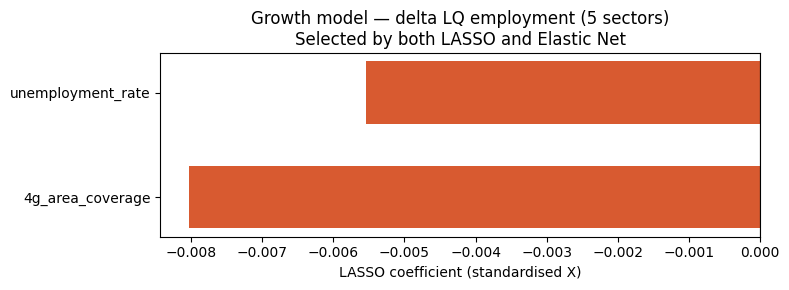

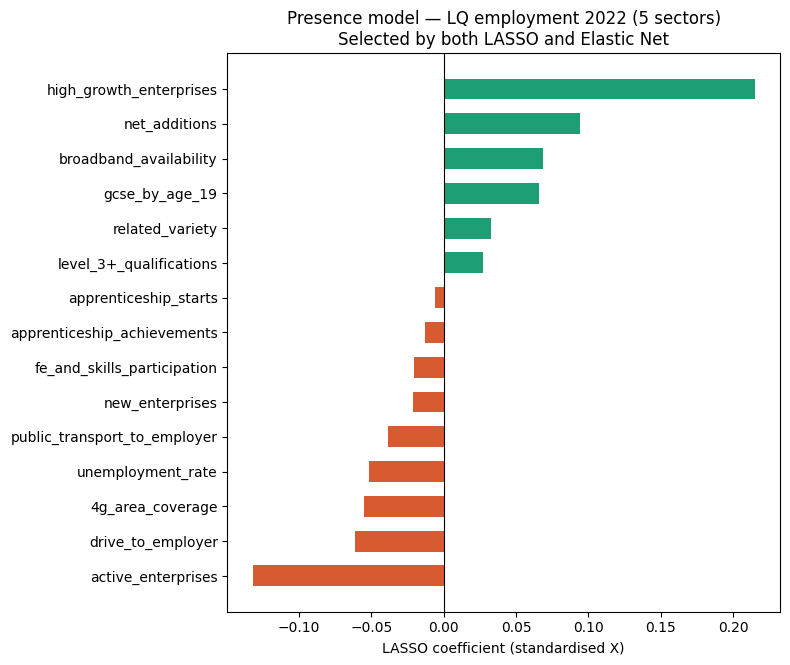

In [35]:
# ────────────────────────────────────────────────────────────
# 7. COEFFICIENT PLOT
# ────────────────────────────────────────────────────────────

def plot_coefs(results, label):
    if results is None:
        return
    sel = results[results["selected_both"] & ~results["is_sector"]].sort_values("lasso_coef")
    if len(sel) == 0:
        print(f"No variables selected for {label}")
        return
    colors = ["#D85A30" if c < 0 else "#1D9E75" for c in sel["lasso_coef"]]
    fig, ax = plt.subplots(figsize=(8, max(3, len(sel) * 0.45)))
    ax.barh(sel["variable"], sel["lasso_coef"], color=colors, height=0.6)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("LASSO coefficient (standardised X)")
    ax.set_title(f"{label}\nSelected by both LASSO and Elastic Net")
    plt.tight_layout()
    fname = label.replace(" ", "_").replace(",", "")[:40]
    plt.savefig(f"lasso_{fname}.png", dpi=150)
    plt.show()

plot_coefs(r1, "Growth model — delta LQ employment (5 sectors)")
plot_coefs(r2, "Presence model — LQ employment 2022 (5 sectors)")

In [51]:
# ── FINAL LOCKED DECISIONS ──────────────────────────────────
# Geography:  England only (Scotland/Wales excluded — indicators England-only)
# Sectors:    5 (Defence excluded — 98.9% zeros; Life Sciences separate)
# Transport:  excluded (missing 17 English LADs)
# Unemployment: excluded (r=-0.07 with outcomes, costs 21 LADs)
# Sample:     ~290 LADs × 5 sectors = ~1,450 rows

LAD_INDICATORS_FINAL_V2 = [
    # Human capital
    "level_3+_qualifications",
    "gcse_by_age_19",
    "apprenticeship_starts",
    "apprenticeship_achievements",
    "fe_and_skills_participation",
    # Entrepreneurial discovery
    "new_enterprises",
    "deaths_of_enterprises",
    "active_enterprises",
    "high_growth_enterprises",
    # Connectivity
    "broadband_availability",
    "4g_area_coverage",
    # Place
    "net_additions",
    # Derived
    "related_variety",
]

# Clean sample
# Rebuild cs_5_eng_clean from scratch WITHOUT dummies
# Start from cs (has is8_sector as a column still)
cs_5_fresh = cs[cs["is8_sector"] != "Life Sciences"].copy()
cs_5_eng_fresh = cs_5_fresh[cs_5_fresh["geography_code"].str.startswith("E")].copy()

# Apply clean filter
cs_5_eng_clean = cs_5_eng_fresh[
    cs_5_eng_fresh[LAD_INDICATORS_FINAL_V2].notna().all(axis=1)
].copy()

print(f"Final sample: {len(cs_5_eng_clean)} rows")
print(f"Unique LADs: {cs_5_eng_clean['geography_code'].nunique()}")
print(f"is8_sector still present: {'is8_sector' in cs_5_eng_clean.columns}")

# NOW add sector dummies on the fresh dataframe
cs_5_eng_clean, sec_final = add_sector_dummies(cs_5_eng_clean)
print(f"Sector dummies: {sec_final}")

# Run models
print("\n>>> MODEL 1: GROWTH — delta_lq_emp")
r1 = run_lasso(cs_5_eng_clean, "delta_lq_emp",
               LAD_INDICATORS_FINAL_V2, sec_final,
               "England, 5 sectors, delta LQ employment")

print("\n>>> MODEL 2: PRESENCE — lq_emp_2022")
r2 = run_lasso(cs_5_eng_clean, "lq_emp_2022",
               LAD_INDICATORS_FINAL_V2, sec_final,
               "England, 5 sectors, LQ employment 2022")

print("\n>>> ROBUSTNESS: lq_bus_2022")
r3 = run_lasso(cs_5_eng_clean, "lq_bus_2022",
               LAD_INDICATORS_FINAL_V2, sec_final,
               "England, 5 sectors, LQ business 2022")

# Stability summary
s1 = selected_lad_vars(r1)
s2 = selected_lad_vars(r2)
s3 = selected_lad_vars(r3)

print("\n" + "="*55)
print("FINAL STABILITY SUMMARY")
print(f"Selected growth + presence (headline): {s1 & s2}")
print(f"Selected all three models (most robust): {s1 & s2 & s3}")
print(f"Growth only:   {s1 - s2}")
print(f"Presence only: {s2 - s1}")

Final sample: 1450 rows
Unique LADs: 290
is8_sector still present: True
Sector dummies: ['is8_sector_Advanced Manufacturing', 'is8_sector_Creative Industries', 'is8_sector_Defence', 'is8_sector_Digital and Technologies', 'is8_sector_Financial Services', 'is8_sector_Life Sciences']

>>> MODEL 1: GROWTH — delta_lq_emp

  England, 5 sectors, delta LQ employment
  N=1450 | lambda=10.00000 | l1_ratio=0.10
  LAD indicators selected by BOTH: 0
  Dropped by both: ['level_3+_qualifications', 'gcse_by_age_19', 'apprenticeship_starts', 'apprenticeship_achievements', 'fe_and_skills_participation', 'new_enterprises', 'deaths_of_enterprises', 'active_enterprises', 'high_growth_enterprises', 'broadband_availability', '4g_area_coverage', 'net_additions', 'related_variety']

>>> MODEL 2: PRESENCE — lq_emp_2022

  England, 5 sectors, LQ employment 2022
  N=1450 | lambda=0.00464 | l1_ratio=0.50
  LAD indicators selected by BOTH: 11
                   variable  lasso_coef  enet_coef
    high_growth_enterp

In [52]:
# Fix 1 — check Defence dummy is not in your data
print("Sectors in clean sample:")
print(cs_5_eng_clean["geography_code"].head(0))  # just check
# Count rows per sector dummy
for col in sec_final:
    print(f"{col}: {cs_5_eng_clean[col].sum():.0f} rows")

# Fix 2 — see ALL 11 selected variables for presence model
print("\nFull presence model results (all 11 variables):")
print(r2[r2["selected_both"] & ~r2["is_sector"]]
      .sort_values("lasso_coef", key=abs, ascending=False)
      [["variable", "lasso_coef", "enet_coef"]]
      .to_string(index=False))

# Fix 3 — see full stability summary
print("\nFull presence-only variables:")
print(sorted(s2))

Sectors in clean sample:
Series([], Name: geography_code, dtype: category
Categories (350, object): ['E06000001', 'E06000002', 'E06000003', 'E06000004', ..., 'W06000021', 'W06000022', 'W06000023', 'W06000024'])
is8_sector_Advanced Manufacturing: 290 rows
is8_sector_Creative Industries: 290 rows
is8_sector_Defence: 0 rows
is8_sector_Digital and Technologies: 290 rows
is8_sector_Financial Services: 290 rows
is8_sector_Life Sciences: 0 rows

Full presence model results (all 11 variables):
                   variable  lasso_coef  enet_coef
    high_growth_enterprises    0.230257   0.226134
         active_enterprises   -0.145248  -0.131408
     broadband_availability    0.102423   0.102668
             gcse_by_age_19    0.083960   0.082844
              net_additions    0.080546   0.080515
    level_3+_qualifications    0.045564   0.045722
           4g_area_coverage   -0.037564  -0.037684
            related_variety    0.024998   0.025058
            new_enterprises   -0.022085  -0.032732

In [53]:
# Fix 1 — drop empty sector dummy columns (Defence, Life Sciences have 0 rows)
sec_final_clean = [c for c in sec_final 
                   if cs_5_eng_clean[c].sum() > 0]
print(f"Valid sector dummies: {sec_final_clean}")

# Fix 2 — confirm England only (no W codes)
nations = cs_5_eng_clean["geography_code"].astype(str).str[0].value_counts()
print(f"\nNation breakdown:\n{nations}")

# If Wales still present, re-filter
cs_5_eng_clean = cs_5_eng_clean[
    cs_5_eng_clean["geography_code"].astype(str).str.startswith("E")
].copy()
print(f"Rows after confirming England only: {len(cs_5_eng_clean)}")

# Fix 3 — re-run presence model with clean dummies
print("\n>>> MODEL 2 FINAL: PRESENCE — lq_emp_2022")
r2_final = run_lasso(cs_5_eng_clean, "lq_emp_2022",
                     LAD_INDICATORS_FINAL_V2, sec_final_clean,
                     "England, 5 sectors, LQ employment 2022")

Valid sector dummies: ['is8_sector_Advanced Manufacturing', 'is8_sector_Creative Industries', 'is8_sector_Digital and Technologies', 'is8_sector_Financial Services']

Nation breakdown:
geography_code
E    1450
Name: count, dtype: int64
Rows after confirming England only: 1450

>>> MODEL 2 FINAL: PRESENCE — lq_emp_2022

  England, 5 sectors, LQ employment 2022
  N=1450 | lambda=0.00464 | l1_ratio=0.50
  LAD indicators selected by BOTH: 11
                   variable  lasso_coef  enet_coef
    high_growth_enterprises    0.230257   0.226134
         active_enterprises   -0.145248  -0.131408
     broadband_availability    0.102423   0.102668
             gcse_by_age_19    0.083960   0.082844
              net_additions    0.080546   0.080515
    level_3+_qualifications    0.045564   0.045722
           4g_area_coverage   -0.037564  -0.037684
            related_variety    0.024998   0.025058
            new_enterprises   -0.022085  -0.032732
apprenticeship_achievements   -0.016430  -0.0172

In [42]:
# See all 15 selected variables for presence model
print(r2[r2["selected_both"] & ~r2["is_sector"]]
      .sort_values("lasso_coef", key=abs, ascending=False)
      [["variable", "lasso_coef", "enet_coef"]]
      .to_string(index=False))

# Check active_enterprises collinearity concern
cols = ["high_growth_enterprises", "active_enterprises", 
        "new_enterprises", "deaths_of_enterprises"]
print("\nCorrelation between enterprise variables:")
print(df[df["year"]==2022][cols].corr().round(2))

                    variable  lasso_coef  enet_coef
     high_growth_enterprises    0.215044   0.163686
          active_enterprises   -0.132163  -0.037765
               net_additions    0.094005   0.091655
      broadband_availability    0.068849   0.061671
              gcse_by_age_19    0.065877   0.056624
           drive_to_employer   -0.061359  -0.052086
            4g_area_coverage   -0.055185  -0.049437
           unemployment_rate   -0.051968  -0.056178
public_transport_to_employer   -0.038593  -0.047018
             related_variety    0.032635   0.028890
     level_3+_qualifications    0.027063   0.028966
             new_enterprises   -0.021080  -0.039525
 fe_and_skills_participation   -0.020335  -0.016825
 apprenticeship_achievements   -0.013104  -0.008022
       apprenticeship_starts   -0.005948  -0.008096

Correlation between enterprise variables:
                         high_growth_enterprises  active_enterprises  \
high_growth_enterprises                     1.00     

For approximately 16-21 LADs (~5%) where no local data was available, missing values were imputed using the national median. These LADs are predominantly smaller or rural authorities with limited data reporting.

In [ ]:
# Columns to exclude from indicators
cols_to_exclude = ['YEAR', 'GEOGRAPHY_CODE', 'GEOGRAPHY_NAME', 
                   'IS8_SECTOR', 'FRONTIER_SECTOR', 
                   'OBS_Value_Business', 'OBS_Value_Employment',
                   'Business_growth_rate', 'Employment_growth_rate']

# X — only local indicators
indicators = X_clean.drop(columns=cols_to_exclude)

In [ ]:
##Imputations
fallback_summary = {}
for col in indicators.columns:
    lads_all_missing = X_clean.groupby('GEOGRAPHY_CODE')[col].apply(
        lambda x: x.isnull().all()
    ).sum()
    fallback_summary[col] = lads_all_missing
    
fallback_df = pd.DataFrame.from_dict(
    fallback_summary, orient='index', columns=['LADs using national median']
)

fallback_df = fallback_df[fallback_df['LADs using national median'] > 0].sort_values(
    'LADs using national median', ascending=False
)
print(fallback_df)
print(f"Total LADs in dataset: {X_clean['GEOGRAPHY_CODE'].nunique()}")

                                                    LADs using national median
Modelled unemployment rate, aged 16 years and o...                          21
Mean satisfaction with your life nowadays score...                          16
Mean feeling things done in life are worthwhile...                          16
Mean happiness yesterday scored 0 (not at all) ...                          16
Mean anxiety yesterday scored 0 (not at all) - ...                          16
Gross Value Added (GVA) per hour worked (£) [GV...                           9
Percentage of 4G coverage by at least one mobil...                           9
Percentage of premises with gigabit-capable bro...                           9
Percentage of adults that currently smoke cigar...                           7
Employment rate, aged 16 to 64 years (%) [Emplo...                           6
Proportion of the population aged 16 to 64 with...                           6
Count of births of new enterprises (control rou...  

In [ ]:
## I will drop of my analysis modelled unemployment rate, as I have the employment variable:




In [ ]:
for col in indicators.columns:
    X_clean[col] = X_clean.groupby('GEOGRAPHY_CODE')[col].transform(
        lambda x: x.fillna(x.median())
    )
    X_clean[col] = X_clean[col].fillna(X_clean[col].median())  # fallback for any remaining missing with the national median 

In [ ]:
X_clean.head(50)

,YEAR,GEOGRAPHY_CODE,GEOGRAPHY_NAME,IS8_SECTOR,FRONTIER_SECTOR,OBS_Value_Business,OBS_Value_Employment,Business_growth_rate,Employment_growth_rate,Gross Value Added (GVA) per hour worked (£) [GVA per hour],...,Count of active enterprises (control rounded to base 5) [Active enterprises],Count of high growth enterprises (control rounded to base 5) [High growth enterprises],Percentage of premises with gigabit-capable broadband (%) [Broadband availability],Percentage of 4G coverage by at least one mobile network operator (%) [4G area coverage],Proportion of the population aged 16 to 64 with NVQ3+ qualification (%) [Level 3+ qualifications],Percentage of adults that currently smoke cigarettes (%) [Smokers],Mean satisfaction with your life nowadays scored 0 (not at all) - 10 (completely) [Life satisfaction],Mean feeling things done in life are worthwhile scored 0 (not at all) - 10 (completely) [Worthwhile],Mean happiness yesterday scored 0 (not at all) - 10 (completely) [Happiness],Mean anxiety yesterday scored 0 (not at all) - 10 (completely) [Anxiety]
0,2022,E06000001,Hartlepool,Professional and Business Services,"Accounting, audit and tax consultancy",25.0,175.0,0.000000,0.839751,29.84,...,2430.0,10.0,91.4,99.98,56.4,14.3,7.29,7.75,7.57,3.48
1,2022,E06000001,Hartlepool,Creative Industries,Advertising and marketing,10.0,15.0,0.000000,-1.558145,29.84,...,2430.0,10.0,91.4,99.98,56.4,14.3,7.29,7.75,7.57,3.48
2,2022,E06000001,Hartlepool,Advanced manufacturing,Aerospace manufacturing,0.0,0.0,0.000000,0.000000,29.84,...,2430.0,10.0,91.4,99.98,56.4,14.3,7.29,7.75,7.57,3.48
3,2022,E06000001,Hartlepool,Advanced manufacturing,Agritech,0.0,0.0,0.000000,0.000000,29.84,...,2430.0,10.0,91.4,99.98,56.4,14.3,7.29,7.75,7.57,3.48
4,2022,E06000001,Hartlepool,Financial Services,Asset management and wholesale services,10.0,45.0,-0.374693,0.245122,29.84,...,2430.0,10.0,91.4,99.98,56.4,14.3,7.29,7.75,7.57,3.48
5,2022,E06000001,Hartlepool,Advanced manufacturing,Automotive manufacturing,0.0,400.0,0.000000,0.000000,29.84,...,2430.0,10.0,91.4,99.98,56.4,14.3,7.29,7.75,7.57,3.48
6,2022,E06000001,Hartlepool,Advanced manufacturing,Batteries,0.0,0.0,0.000000,0.000000,29.84,...,2430.0,10.0,91.4,99.98,56.4,14.3,7.29,7.75,7.57,3.48
7,2022,E06000001,Hartlepool,Financial Services,Capital markets and retail investment,20.0,90.0,0.271934,0.056512,29.84,...,2430.0,10.0,91.4,99.98,56.4,14.3,7.29,7.75,7.57,3.48
8,2022,E06000001,Hartlepool,Defence sector,Defence Sector,0.0,0.0,0.000000,0.000000,29.84,...,2430.0,10.0,91.4,99.98,56.4,14.3,7.29,7.75,7.57,3.48
9,2022,E06000001,Hartlepool,Digital and Technology,Digital and Technology,285.0,1395.0,-0.146126,-0.055725,29.84,...,2430.0,10.0,91.4,99.98,56.4,14.3,7.29,7.75,7.57,3.48


In [ ]:
lad_vars = (
    X_clean[X_clean["FRONTIER_SECTOR"] == "Total"]
    .groupby("GEOGRAPHY_CODE")
    .agg(
        GEOGRAPHY_NAME  = ("GEOGRAPHY_NAME", "first"),
        Business_growth = ("Business_growth_rate", "first"),  # adjust col name
        Employ_growth   = ("Employ_growth_rate",   "first"),  # adjust col name
        total_bus       = ("OBS_Value_Business", "first"),
        total_emp       = ("OBS_Value_Employment",  "first"),
    )
    .reset_index()
)

# 1b. Calculate sector shares from non-Total rows
sectors = X_clean[X_clean["FRONTIER_SECTOR"] != "Total"].copy()
sectors = sectors.merge(
    lad_vars[["GEOGRAPHY_CODE", "total_bus", "total_emp"]],
    on="GEOGRAPHY_CODE"
)

# Enterprise share per sector
sectors["ent_share"] = sectors["OBS_Value_Business"] / sectors["total_bus"]
# Employment share per sector
sectors["emp_share"] = sectors["OBS_Value_Employment"]  / sectors["total_emp"]

# 1c. Pivot to wide — one column per Frontier sector
ent_wide = sectors.pivot_table(
    index="GEOGRAPHY_CODE", columns="FRONTIER_SECTOR", values="ent_share"
)
ent_wide.columns = [f"ent_share_{c}" for c in ent_wide.columns]

emp_wide = sectors.pivot_table(
    index="GEOGRAPHY_CODE", columns="FRONTIER_SECTOR", values="emp_share"
)
emp_wide.columns = [f"emp_share_{c}" for c in emp_wide.columns]

# 1d. Merge everything together
df_wide = (
    lad_vars
    .set_index("GEOGRAPHY_CODE")
    .join(ent_wide)
    .join(emp_wide)
    .reset_index()
)

print(f"Wide dataset shape: {df_wide.shape}")  # should be ~350 rows
print(df_wide.head())


In [ ]:
ddddd

NameError: name 'ddddd' is not defined

In [ ]:
X = X_clean[indicators.columns].copy()
y_bus = X_clean['Business_growth_rate'].reset_index(drop=True)
y_emp = X_clean['Employment_growth_rate'].reset_index(drop=True)

print(f'X shape: {X.shape}, y_business growth shape: {y_bus.shape}, y_employment growth shape: {y_emp.shape}')

X shape: (7810, 17), y_business growth shape: (7810,), y_employment growth shape: (7810,)


In [ ]:
# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=indicators.columns, 
                            index=X_clean.index)

# Sector dummies
is8_dummies     = pd.get_dummies(X_clean['IS8_SECTOR'], 
                                  prefix='IS8', drop_first=True)
frontier_dummies = pd.get_dummies(X_clean['FRONTIER_SECTOR'], 
                                   prefix='FS', drop_first=True)

In [ ]:
cddddd

In [ ]:
##### LASSO — variable selection 
lasso_bus = LassoCV(cv=10, random_state=42, max_iter=10000).fit(X_scaled, y_bus)
lasso_emp = LassoCV(cv=10, random_state=42, max_iter=10000).fit(X_scaled, y_emp)

selected_bus = [col for col, coef in zip(indicators.columns, lasso_bus.coef_) if coef != 0]
selected_emp = [col for col, coef in zip(indicators.columns, lasso_emp.coef_) if coef != 0]

# LASSO coefficients summary
lasso_bus_df = pd.DataFrame({
    'Variable'   : indicators.columns,
    'Coefficient': lasso_bus.coef_
}).query('Coefficient != 0').sort_values('Coefficient', key=abs, ascending=False)

lasso_emp_df = pd.DataFrame({
    'Variable'   : indicators.columns,
    'Coefficient': lasso_emp.coef_
}).query('Coefficient != 0').sort_values('Coefficient', key=abs, ascending=False)


C:\Users\diane\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.903e+00, tolerance: 2.159e-01
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\diane\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.078e+01, tolerance: 2.159e-01
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\diane\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or c

In [ ]:
print(f"LASSO — Business growth selected {len(selected_bus)} variables:")
print(lasso_bus_df.to_string(index=False))

LASSO — Business growth selected 8 variables:
                                                                                             Variable  Coefficient
                                           Gross Value Added (GVA) per hour worked (£) [GVA per hour]    -0.009159
                                                             Gross median weekly pay (£) [Weekly pay]    -0.007358
    Proportion of the population aged 16 to 64 with NVQ3+ qualification (%) [Level 3+ qualifications]     0.006564
                             Mean anxiety yesterday scored 0 (not at all) - 10 (completely) [Anxiety]    -0.004866
                   Percentage of premises with gigabit-capable broadband (%) [Broadband availability]    -0.004678
                                   Percentage of adults that currently smoke cigarettes (%) [Smokers]     0.004444
                                           Employment rate, aged 16 to 64 years (%) [Employment rate]     0.002566
Mean satisfaction with your life n

In [ ]:
print(f"LASSO — Employment growth selected {len(selected_emp)} variables:")
print(lasso_emp_df.to_string(index=False))

LASSO — Employment growth selected 0 variables:
Empty DataFrame
Columns: [Variable, Coefficient]
Index: []


In [ ]:
# ── Sector dummies ────────────────────────────────────────────────
is8_dummies      = pd.get_dummies(X_clean['IS8_SECTOR'],      drop_first=True).astype(float)
frontier_dummies = pd.get_dummies(X_clean['FRONTIER_SECTOR'], drop_first=True).astype(float)

In [ ]:
# ── Modelos CON estandarización ───────────────────────────────────
def run_ols_scaled(y, dummies, label):
    X_ols = pd.concat([
        X_scaled_df[indicators.columns].reset_index(drop=True),
        dummies.reset_index(drop=True)
    ], axis=1).astype(float)
    X_ols = sm.add_constant(X_ols)
    model = sm.OLS(y, X_ols).fit(cov_type='HC3')
    print(f"\n{'='*60}")
    print(f"MODEL (SCALED): {label}")
    print(model.summary())
    return model

# ── Modelos SIN estandarización ───────────────────────────────────
def run_ols_raw(y, dummies, label):
    X_ols = pd.concat([
        X_clean[indicators.columns].reset_index(drop=True),
        dummies.reset_index(drop=True)
    ], axis=1).astype(float)
    X_ols = sm.add_constant(X_ols)
    model = sm.OLS(y, X_ols).fit(cov_type='HC3')
    print(f"\n{'='*60}")
    print(f"MODEL (RAW): {label}")
    print(model.summary())
    return model

### IS8 FIXED EFFECTS

Business outcome

In [ ]:

print("IS8 with standarized local indicators")
m1_scaled = run_ols_scaled(y_bus, is8_dummies, "M1: Business Growth   + IS8 FE")

IS8 with standarized local indicators

MODEL (SCALED): M1: Business Growth   + IS8 FE
                             OLS Regression Results                             
Dep. Variable:     Business_growth_rate   R-squared:                       0.253
Model:                              OLS   Adj. R-squared:                  0.250
Method:                   Least Squares   F-statistic:                     6.821
Date:                  Sun, 15 Mar 2026   Prob (F-statistic):           1.38e-21
Time:                          15:45:56   Log-Likelihood:                -61410.
No. Observations:                  6035   AIC:                         1.229e+05
Df Residuals:                      6011   BIC:                         1.230e+05
Df Model:                            23                                         
Covariance Type:                    HC3                                         
                                                                                                        

In [ ]:
print("IS8 without standarized local indicators")
m1_raw    = run_ols_raw   (y_bus, is8_dummies, "M1: Business Growth   + IS8 FE")

IS8 without standarized local indicators



MODEL (RAW): M1: Business Growth   + IS8 FE
                             OLS Regression Results                             
Dep. Variable:     Business_growth_rate   R-squared:                       0.253
Model:                              OLS   Adj. R-squared:                  0.250
Method:                   Least Squares   F-statistic:                     6.821
Date:                  Sun, 15 Mar 2026   Prob (F-statistic):           1.38e-21
Time:                          15:45:56   Log-Likelihood:                -61410.
No. Observations:                  6035   AIC:                         1.229e+05
Df Residuals:                      6011   BIC:                         1.230e+05
Df Model:                            23                                         
Covariance Type:                    HC3                                         
                                                                                                            coef    std err          z      P>|z|

Employment outcome

In [ ]:
#With standarizaed local indicators
m2_scaled = run_ols_scaled(y_emp, is8_dummies, "M2: Employment Growth + IS8 FE")



MODEL (SCALED): M2: Employment Growth + IS8 FE
                              OLS Regression Results                              
Dep. Variable:     Employment_growth_rate   R-squared:                       0.295
Model:                                OLS   Adj. R-squared:                  0.292
Method:                     Least Squares   F-statistic:                     11.13
Date:                    Sun, 15 Mar 2026   Prob (F-statistic):           2.88e-40
Time:                            15:45:56   Log-Likelihood:                -73160.
No. Observations:                    6035   AIC:                         1.464e+05
Df Residuals:                        6011   BIC:                         1.465e+05
Df Model:                              23                                         
Covariance Type:                      HC3                                         
                                                                                                            coef    std er

In [ ]:
#Without standarised local indicators
m2_raw    = run_ols_raw   (y_emp, is8_dummies, "M2: Employment Growth + IS8 FE")


MODEL (RAW): M2: Employment Growth + IS8 FE
                              OLS Regression Results                              
Dep. Variable:     Employment_growth_rate   R-squared:                       0.295
Model:                                OLS   Adj. R-squared:                  0.292
Method:                     Least Squares   F-statistic:                     11.13
Date:                    Sun, 15 Mar 2026   Prob (F-statistic):           2.88e-40
Time:                            15:45:56   Log-Likelihood:                -73160.
No. Observations:                    6035   AIC:                         1.464e+05
Df Residuals:                        6011   BIC:                         1.465e+05
Df Model:                              23                                         
Covariance Type:                      HC3                                         
                                                                                                            coef    std err  

## FRONTIER SECTOR FIXED EFFECTS

Business outcome

In [ ]:
# With standarised local indicators
m3_scaled = run_ols_scaled(y_bus, frontier_dummies, "M3: Business Growth   + Frontier FE")



MODEL (SCALED): M3: Business Growth   + Frontier FE
                             OLS Regression Results                             
Dep. Variable:     Business_growth_rate   R-squared:                       0.255
Model:                              OLS   Adj. R-squared:                  0.251
Method:                   Least Squares   F-statistic:                     31.21
Date:                  Sun, 15 Mar 2026   Prob (F-statistic):          7.68e-179
Time:                          15:45:56   Log-Likelihood:                -61405.
No. Observations:                  6035   AIC:                         1.229e+05
Df Residuals:                      6001   BIC:                         1.231e+05
Df Model:                            33                                         
Covariance Type:                    HC3                                         
                                                                                                            coef    std err          z   

In [ ]:
# Without standarised local indicators
m3_raw    = run_ols_raw   (y_bus, frontier_dummies, "M3: Business Growth   + Frontier FE")


MODEL (RAW): M3: Business Growth   + Frontier FE
                             OLS Regression Results                             
Dep. Variable:     Business_growth_rate   R-squared:                       0.255
Model:                              OLS   Adj. R-squared:                  0.251
Method:                   Least Squares   F-statistic:                     31.21
Date:                  Sun, 15 Mar 2026   Prob (F-statistic):          7.70e-179
Time:                          15:45:56   Log-Likelihood:                -61405.
No. Observations:                  6035   AIC:                         1.229e+05
Df Residuals:                      6001   BIC:                         1.231e+05
Df Model:                            33                                         
Covariance Type:                    HC3                                         
                                                                                                            coef    std err          z      

Employment outcome

In [ ]:
m4_scaled = run_ols_scaled(y_emp, frontier_dummies, "M4: Employment Growth + Frontier FE")


MODEL (SCALED): M4: Employment Growth + Frontier FE
                              OLS Regression Results                              
Dep. Variable:     Employment_growth_rate   R-squared:                       0.295
Model:                                OLS   Adj. R-squared:                  0.291
Method:                     Least Squares   F-statistic:                     21.08
Date:                    Sun, 15 Mar 2026   Prob (F-statistic):          1.10e-117
Time:                            15:45:57   Log-Likelihood:                -73159.
No. Observations:                    6035   AIC:                         1.464e+05
Df Residuals:                        6001   BIC:                         1.466e+05
Df Model:                              33                                         
Covariance Type:                      HC3                                         
                                                                                                            coef    s

In [ ]:
m4_raw    = run_ols_raw   (y_emp, frontier_dummies, "M4: Employment Growth + Frontier FE")


MODEL (RAW): M4: Employment Growth + Frontier FE
                              OLS Regression Results                              
Dep. Variable:     Employment_growth_rate   R-squared:                       0.295
Model:                                OLS   Adj. R-squared:                  0.291
Method:                     Least Squares   F-statistic:                     21.08
Date:                    Sun, 15 Mar 2026   Prob (F-statistic):          1.11e-117
Time:                            15:45:57   Log-Likelihood:                -73159.
No. Observations:                    6035   AIC:                         1.464e+05
Df Residuals:                        6001   BIC:                         1.466e+05
Df Model:                              33                                         
Covariance Type:                      HC3                                         
                                                                                                            coef    std 